In [1]:
# Librerías necesarias
from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from tensorflow.keras import layers

# Cargamos datos y prueba de CIFAR10
(imgs_train,labs_train), (imgs_test,labs_test) = keras.datasets.cifar10.load_data()

# Nombres de las clases
nombres = ['avión', 'auto', 'pájaro', 'gato', 'venado', 'perro', 'rana', 'caballo', 'barco', 'camión']

# 1. Aplanamiento (Flattening): Convertimos cada imagen de 32x32x3 a un vector 1D de 3072 elementos
X_train = imgs_train.reshape(imgs_train.shape[0], -1)
X_test = imgs_test.reshape(imgs_test.shape[0], -1)

# 2. Normalización: Llevamos los pixeles de un rango 0-255 a 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. One-Hot Encoding: Convertimos las etiquetas numéricas a formato categórico
Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de Y_train: {Y_train.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Dimensiones de X_train: (50000, 3072)
Dimensiones de Y_train: (50000, 10)


In [2]:
# Construcción del modelo Perceptrón Multicapa (MLP)
red = keras.Sequential([
    # Capa de entrada y primera capa oculta
    layers.Dense(512, activation='relu', input_shape=(3072,)),

    # Segunda capa oculta
    layers.Dense(256, activation='relu'),

    # Tercera capa oculta
    layers.Dense(128, activation='relu'),

    # Capa de salida: 10 neuronas (una por clase)
    layers.Dense(10, activation='softmax')
])

# Compilación del modelo
red.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostramos el resumen de la arquitectura
red.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Iniciando el entrenamiento del modelo base...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.3250 - loss: 1.8636 - val_accuracy: 0.3924 - val_loss: 1.7183
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.3979 - loss: 1.6729 - val_accuracy: 0.3915 - val_loss: 1.6941
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.4332 - loss: 1.5802 - val_accuracy: 0.4353 - val_loss: 1.5808
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.4536 - loss: 1.5282 - val_accuracy: 0.4598 - val_loss: 1.5172
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.4674 - loss: 1.4857 - val_accuracy: 0.4735 - val_loss: 1.4756
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.4827 - loss: 1.4476 - val_accuracy: 0.4791 - val_loss: 1.4644
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4924 - loss: 1.4168 - val_accuracy: 0.4728 - val_loss: 1.4751
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 

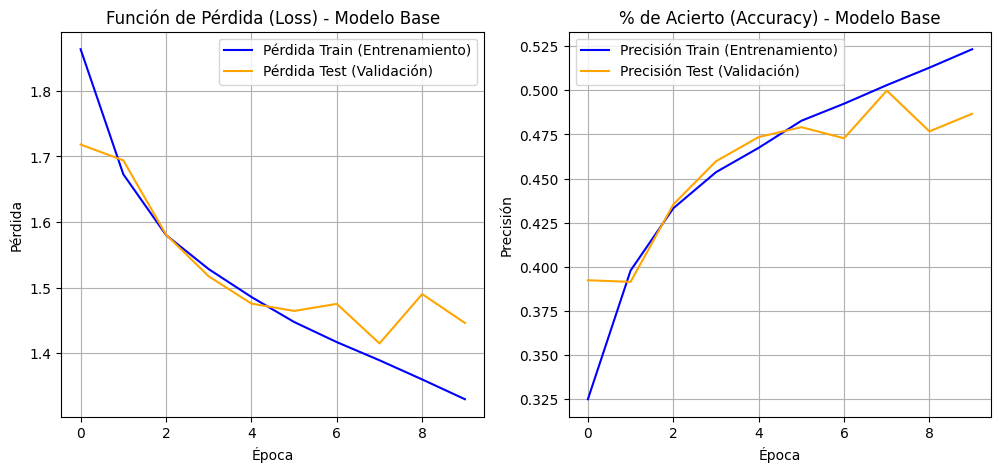

In [3]:
# Definimos hiperparámetros iniciales
epocas = 10
tamano_lote = 64

print("Iniciando el entrenamiento del modelo base...")

# Entrenamos la red y guardamos el proceso en 'historial_base' para poder graficarlo
historial_base = red.fit(
    X_train, Y_train,
    epochs=epocas,
    batch_size=tamano_lote,
    validation_data=(X_test, Y_test) # Usamos los datos de prueba para validar en cada época
)

# --- Creación de los Gráficos de Rendimiento ---

# Graficar la Función de Pérdida (Loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(historial_base.history['loss'], label='Pérdida Train (Entrenamiento)', color='blue')
plt.plot(historial_base.history['val_loss'], label='Pérdida Test (Validación)', color='orange')
plt.title('Función de Pérdida (Loss) - Modelo Base')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Graficar la Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(historial_base.history['accuracy'], label='Precisión Train (Entrenamiento)', color='blue')
plt.plot(historial_base.history['val_accuracy'], label='Precisión Test (Validación)', color='orange')
plt.title('% de Acierto (Accuracy) - Modelo Base')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.show()

Construyendo el Modelo Optimizado...
Iniciando el entrenamiento del modelo optimizado...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.2171 - loss: 2.0814 - val_accuracy: 0.3208 - val_loss: 1.8955
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.2707 - loss: 1.9547 - val_accuracy: 0.3359 - val_loss: 1.8641
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.2818 - loss: 1.9224 - val_accuracy: 0.3384 - val_loss: 1.8444
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.2904 - loss: 1.9043 - val_accuracy: 0.3489 - val_loss: 1.8335
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.3008 - loss: 1.8830 - val_accuracy: 0.3324 - val_loss: 1.8556
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.2974 - loss: 1.8822 - val_accuracy: 0.3575 - val_loss: 1.8358
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.3070 - loss: 1.8724 - val_accuracy: 0.3624 - val_loss: 1.8007
E

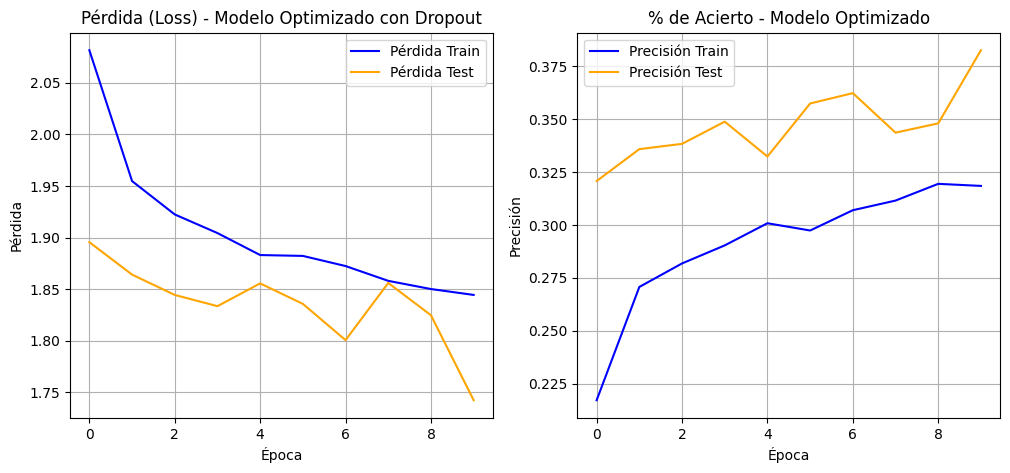

In [4]:
# Importamos la capa Dropout
from tensorflow.keras.layers import Dropout

print("Construyendo el Modelo Optimizado...")

# Construcción del modelo con Regularización (Dropout)
red_optimizada = keras.Sequential([
    # Capa de entrada y primera capa oculta
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3), # Apagamos el 30% de las neuronas aleatoriamente

    # Segunda capa oculta
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Tercera capa oculta
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Capa de salida
    layers.Dense(10, activation='softmax')
])

# Compilación del nuevo modelo
red_optimizada.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Iniciando el entrenamiento del modelo optimizado...")

# Entrenamos la nueva red
historial_optimizado = red_optimizada.fit(
    X_train, Y_train,
    epochs=epocas,
    batch_size=tamano_lote,
    validation_data=(X_test, Y_test)
)

# --- Creación de los Gráficos Comparativos ---

plt.figure(figsize=(12, 5))

# Graficamos la Función de Pérdida (Loss) del modelo optimizado
plt.subplot(1, 2, 1)
plt.plot(historial_optimizado.history['loss'], label='Pérdida Train', color='blue')
plt.plot(historial_optimizado.history['val_loss'], label='Pérdida Test', color='orange')
plt.title('Pérdida (Loss) - Modelo Optimizado con Dropout')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Graficamos la Precisión (Accuracy) del modelo optimizado
plt.subplot(1, 2, 2)
plt.plot(historial_optimizado.history['accuracy'], label='Precisión Train', color='blue')
plt.plot(historial_optimizado.history['val_accuracy'], label='Precisión Test', color='orange')
plt.title('% de Acierto - Modelo Optimizado')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.show()

In [5]:
from sklearn.metrics import classification_report
import numpy as np

print("Generando predicciones con el modelo optimizado para evaluar métricas...")

# 1. Hacemos que la red prediga las clases para las 10,000 imágenes de prueba
predicciones_probabilidades = red_optimizada.predict(X_test)

# 2. Las predicciones son probabilidades (ej: 90% perro, 10% gato).
# Usamos argmax para quedarnos con la clase que tenga mayor probabilidad.
clases_predichas = np.argmax(predicciones_probabilidades, axis=1)

# 3. Convertimos las etiquetas reales de formato One-Hot (0001000...) a un solo número (ej: 3)
clases_reales = np.argmax(Y_test, axis=1)

# 4. Generamos el reporte con todas las métricas requeridas
reporte = classification_report(clases_reales, clases_predichas, target_names=nombres)

print("\n--- Reporte de Clasificación (Modelo Optimizado) ---")
print(reporte)

Generando predicciones con el modelo optimizado para evaluar métricas...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

--- Reporte de Clasificación (Modelo Optimizado) ---
              precision    recall  f1-score   support

       avión       0.50      0.37      0.42      1000
        auto       0.57      0.48      0.52      1000
      pájaro       0.18      0.02      0.04      1000
        gato       0.23      0.26      0.24      1000
      venado       0.31      0.43      0.36      1000
       perro       0.38      0.32      0.35      1000
        rana       0.35      0.55      0.43      1000
     caballo       0.36      0.48      0.41      1000
       barco       0.46      0.45      0.46      1000
      camión       0.45      0.46      0.46      1000

    accuracy                           0.38     10000
   macro avg       0.38      0.38      0.37     10000
weighted avg       0.38      0.38      0.37     10000

